In [1]:
# P1.0 导入库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
%matplotlib inline

In [2]:
# P1.1 读入训练集
df_train = pd.read_csv('./dataset/train.csv')
df_train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [3]:
# P1.2 SalePrice的统计特征
df_train['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

C:\Users\admin\AppData\Roaming\Python\Python36\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


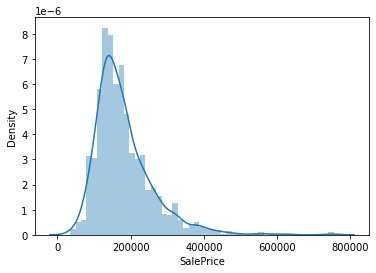

In [4]:
# P1.4 房价直方图
sns.distplot(df_train['SalePrice']);

In [5]:
# P1.3 偏度和峰度
print('偏度: {:.2f}'.format(df_train['SalePrice'].skew()))
print('峰度: {:.2f}'.format(df_train['SalePrice'].kurt()))

偏度: 1.88
峰度: 6.54


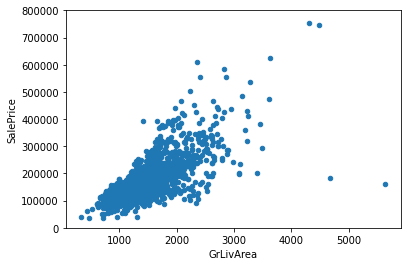

In [6]:
# P1.4 GrLivArea 与 SalePrice关系
var = 'GrLivArea'
data = pd.concat([df_train['SalePrice'], df_train[var]], axis=1)
data.plot.scatter(x=var, y='SalePrice', ylim=(0,800000));

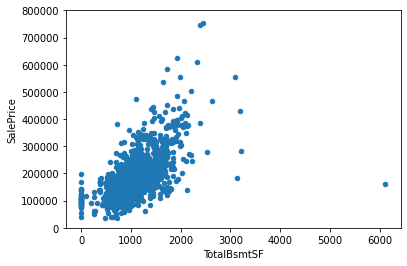

In [7]:
# P1.4 TotalBsmtSF 与 SalePrice 关系
var = 'TotalBsmtSF'
data = pd.concat([df_train['SalePrice'], df_train[var]], axis=1)
data.plot.scatter(x=var, y='SalePrice', ylim=(0,800000));

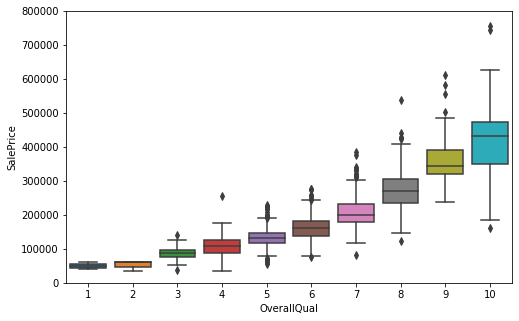

In [8]:
# P1.4 OverallQual 与 SalePrice关系
var = 'OverallQual'
data = pd.concat([df_train['SalePrice'], df_train[var]], axis=1)
f, ax = plt.subplots(figsize=(8, 5))
fig = sns.boxplot(x=var, y="SalePrice", data=data)
fig.axis(ymin=0, ymax=800000);

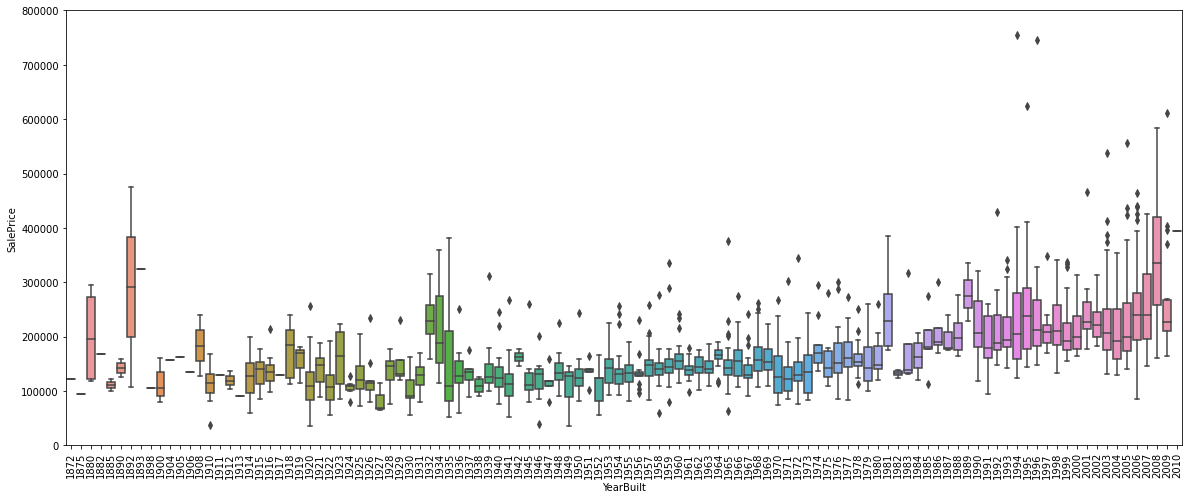

In [9]:
# P1.4 YearBuilt与SalePrice关系
var = 'YearBuilt'
data = pd.concat([df_train['SalePrice'], df_train[var]], axis=1)
f, ax = plt.subplots(figsize=(20, 8))
fig = sns.boxplot(x=var, y="SalePrice", data=data)
fig.axis(ymin=0, ymax=800000);
plt.xticks(rotation=90);

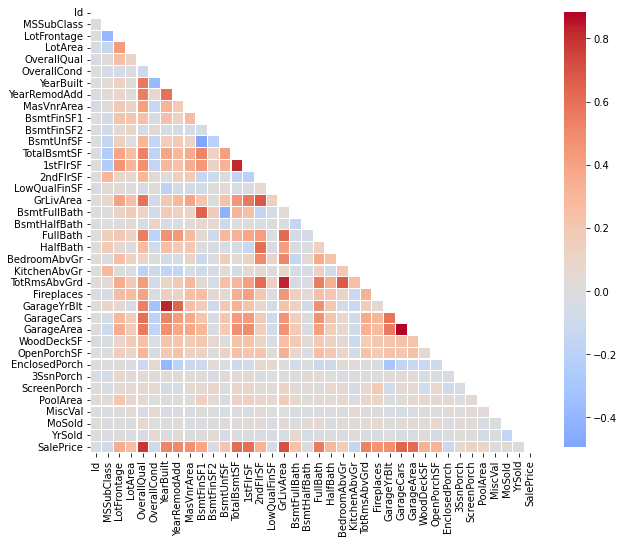

In [10]:
# P1.4 相关矩阵
corrmat = df_train.corr()
mask = np.zeros_like(corrmat, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True
f, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(corrmat, mask=mask, cmap="coolwarm", center=0,
            square=True, linewidths=.2, cbar_kws={"shrink":.8});

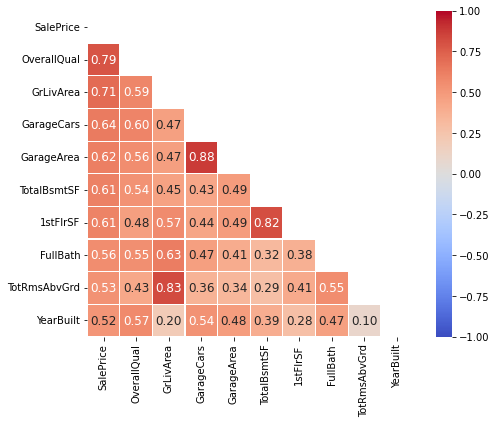

In [11]:
# P1.4 最相关矩阵
k = 10 # 只显示十组变量
cols = corrmat.nlargest(k, 'SalePrice')['SalePrice'].index
cm = np.corrcoef(df_train[cols].values.T)
mask = np.zeros_like(cm, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True
f, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, mask=mask, annot=True, fmt='.2f', cmap="coolwarm", 
            vmax=1, vmin=-1, square=True, linewidths=.2, annot_kws={'size': 12}, 
            yticklabels=cols.values, xticklabels=cols.values);

In [12]:
# P1.5 缺失数据统计
total = df_train.isnull().sum().sort_values(ascending=False)
percent = (df_train.isnull().sum()/df_train.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data[missing_data.Total>0]

,Total,Percent
PoolQC,1453,0.995205
MiscFeature,1406,0.963014
Alley,1369,0.937671
Fence,1179,0.807534
FireplaceQu,690,0.472603
LotFrontage,259,0.177397
GarageCond,81,0.055479
GarageType,81,0.055479
GarageYrBlt,81,0.055479
GarageFinish,81,0.055479


In [13]:
# P1.5 缺失数据清洗
df_train = df_train.drop((missing_data[missing_data['Total'] > 1]).index,1)
df_train = df_train.drop(df_train.loc[df_train['Electrical'].isnull()].index)
print(df_train.isnull().sum().max()) # 重新统计缺失数据
print(df_train.shape)

0
(1459, 63)


In [14]:
# P1.6 删除GrLivArea离群值
df_train.sort_values(by = 'GrLivArea', ascending = False)[:2]
df_train = df_train.drop(df_train[df_train['Id'] == 1299].index)
df_train = df_train.drop(df_train[df_train['Id'] == 524].index)

In [15]:
# P1.6 删除TotalBsmtSF离群值
df_train.sort_values(by = 'TotalBsmtSF', ascending = False)[:1]
df_train = df_train.drop(df_train[df_train['Id'] == 333].index)
print(df_train.shape)
df_train_copy = df_train.copy()

(1456, 63)


C:\Users\admin\AppData\Roaming\Python\Python36\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


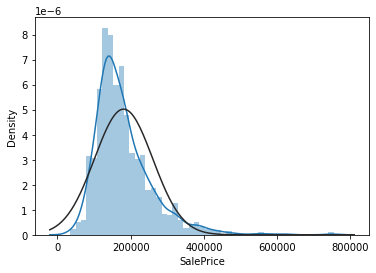

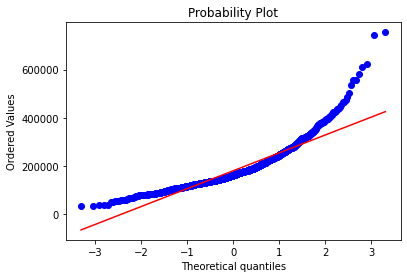

In [16]:
# P1.7 绘制SalePrice的直方图与概率图
sns.distplot(df_train['SalePrice'], fit=norm);
fig = plt.figure()
res = stats.probplot(df_train['SalePrice'], plot=plt)

C:\Users\admin\AppData\Roaming\Python\Python36\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


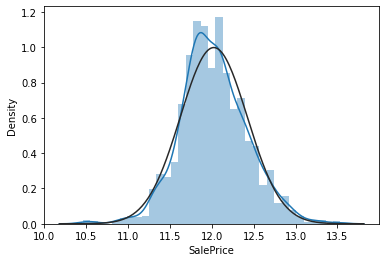

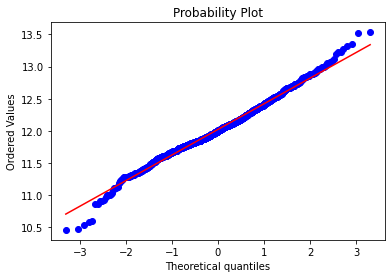

In [17]:
# P1.7 对数变换
df_train['SalePrice'] = np.log1p(df_train['SalePrice'])
# 绘制调整后的直方图与概率图
sns.distplot(df_train['SalePrice'], fit=norm);
fig = plt.figure()
res = stats.probplot(df_train['SalePrice'], plot=plt)

C:\Users\admin\AppData\Roaming\Python\Python36\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


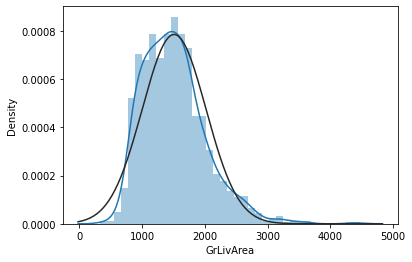

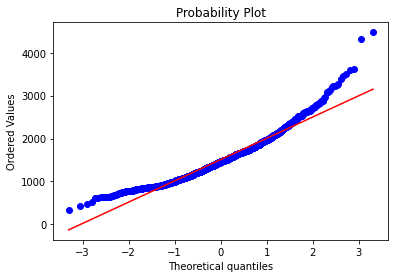

In [18]:
# P1.7 GrLivArea直方图与概率图
sns.distplot(df_train['GrLivArea'], fit=norm);
fig = plt.figure()
res = stats.probplot(df_train['GrLivArea'], plot=plt)

C:\Users\admin\AppData\Roaming\Python\Python36\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


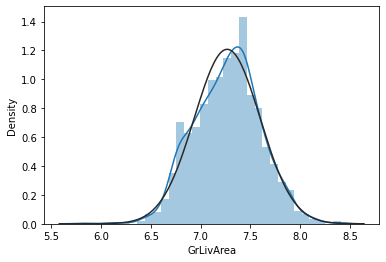

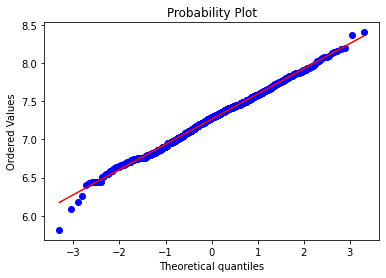

In [19]:
# P1.7 GrLivArea对数变换
df_train['GrLivArea'] = np.log1p(df_train['GrLivArea'])
# GrLivArea对数变换后的直方图与概率图
sns.distplot(df_train['GrLivArea'], fit=norm);
fig = plt.figure()
res = stats.probplot(df_train['GrLivArea'], plot=plt)

C:\Users\admin\AppData\Roaming\Python\Python36\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


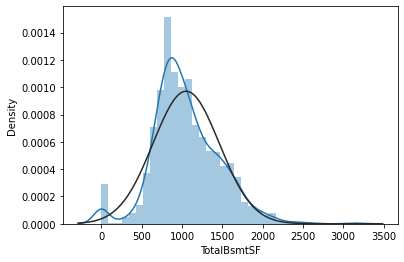

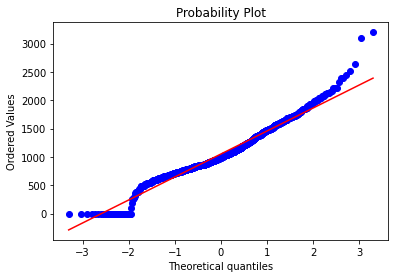

In [20]:
# P1.7 TotalBsmtSF 的直方图与概率图
sns.distplot(df_train['TotalBsmtSF'], fit=norm);
fig = plt.figure()
res = stats.probplot(df_train['TotalBsmtSF'], plot=plt)

C:\Users\admin\AppData\Roaming\Python\Python36\site-packages\seaborn\_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


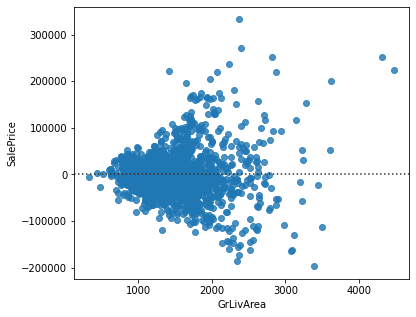

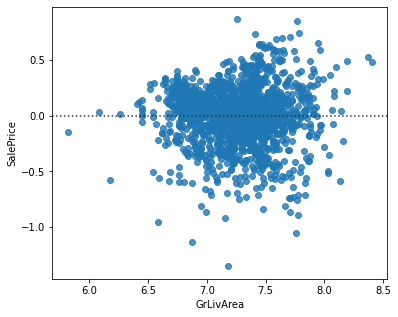

In [21]:
# P1.8 GrLivArea 与 SalePrice 的残差图
# 对数变换前，GrLivArea 与 SalePrice 的残差图
plt.subplots(figsize = (6,5))
sns.residplot(df_train_copy.GrLivArea, df_train_copy.SalePrice);
# 对数变换后，GrLivArea 与 SalePrice 的残差图
plt.subplots(figsize = (6,5))
sns.residplot(df_train.GrLivArea, df_train.SalePrice);

In [22]:
# P1.9 手工计算 beta 系数值 
sample_train=df_train.copy()
y_avg = sample_train.SalePrice.mean()
x_avg = sample_train.GrLivArea.mean()
std_y = sample_train.SalePrice.std()
std_x = sample_train.GrLivArea.std()
r_xy = sample_train.corr().loc['GrLivArea','SalePrice']
beta_1 = r_xy*(std_y/std_x)
beta_0 = y_avg - beta_1*x_avg

In [23]:
# P1.10 计算预测值 y_hat 
sample_train['Yhat'] = beta_0 + beta_1*sample_train['GrLivArea']
sample_train[['SalePrice','Yhat']].head() 

,SalePrice,Yhat
0,12.247699,12.182637
1,12.109016,11.911687
2,12.317171,12.221425
3,11.849405,12.186281
4,12.429220,12.406586


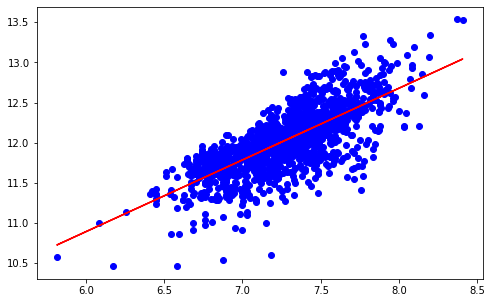

In [24]:
# P1.10 绘制回归直线图
fig = plt.figure(figsize=(8,5))
ax = plt.gca()
ax.scatter(sample_train.GrLivArea, sample_train.SalePrice, c='b')
ax.plot(sample_train['GrLivArea'], sample_train['Yhat'], color='r');

In [25]:
# P1.10 均方误差(MSE)，计算方法1
print("均方误差(MSE) : {}".
      format(np.square(sample_train['SalePrice'] - sample_train['Yhat']).mean()))

均方误差(MSE) : 0.07281647980414091


In [26]:
# P1.10 均方误差(MSE)，计算方法2
from sklearn.metrics import mean_squared_error
mean_squared_error(sample_train['SalePrice'], sample_train.Yhat)

0.07281647980414087

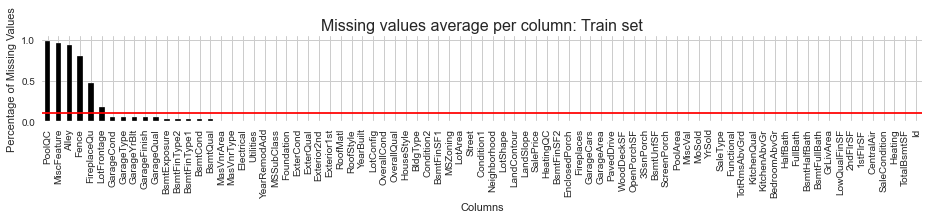

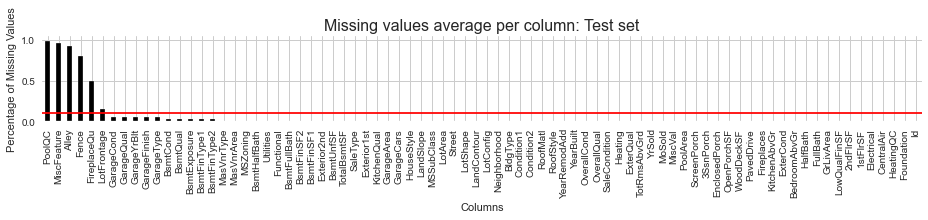

In [27]:
# P1.12 读入数据集，绘图观察缺失数据
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
train = pd.read_csv('./dataset/train.csv')
test = pd.read_csv('./dataset/test.csv')
    
plt.style.use('seaborn') 
sns.set_style('whitegrid')
fig1, ax1 = plt.subplots(1, 1, figsize=(13, 3))

# 计算缺失率并排序
train_missing = train.isnull().mean().sort_values(ascending=False)
train_missing.plot.bar(color='black', ax=ax1)
ax1.axhline(y=0.1, color='r', linestyle='-')
ax1.set_title('Missing values average per column: Train set', fontsize=16)
ax1.set_xlabel('Columns')
ax1.set_ylabel('Percentage of Missing Values')

plt.tight_layout() 
plt.show()


# --- 绘制测试集缺失值 ---
fig2, ax2 = plt.subplots(1, 1, figsize=(13, 3))

test_missing = test.isnull().mean().sort_values(ascending=False)
test_missing.plot.bar(color='black', ax=ax2)

ax2.axhline(y=0.1, color='r', linestyle='-')
ax2.set_title('Missing values average per column: Test set', fontsize=16)
ax2.set_xlabel('Columns')
ax2.set_ylabel('Percentage of Missing Values')

plt.tight_layout()
plt.show()

In [28]:
# P1.12 合并训练集与测试集
rows_train = train.shape[0]
rows_test = test.shape[0]
train_label = train['SalePrice'].to_frame()
combined = pd.concat((train, test), sort=False).reset_index(drop=True)
combined.drop(['SalePrice'], axis=1, inplace=True)
combined.drop(['Id'], axis=1, inplace=True)
print("合并后的数据集维度 :",combined.shape)

合并后的数据集维度 : (2919, 79)


从合并集中删除了 6 个特征


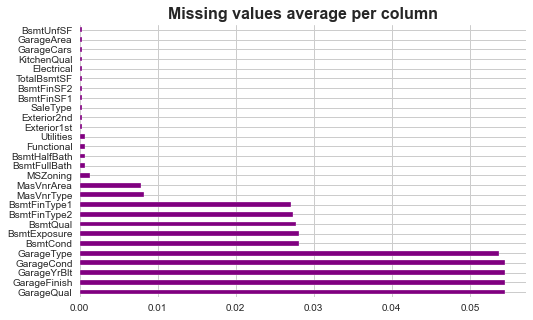

In [29]:
# P1.12	清除缺失率超过15%的特征，绘图显示其他特征缺失率
combined2=combined.dropna(thresh=len(combined)*0.85, axis=1)
print('从合并集中删除了',combined.shape[1]-combined2.shape[1], '个特征')
allna = (combined2.isnull().sum() / len(combined2))
allna = allna.drop(allna[allna == 0].index).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
allna.plot.barh(color='purple')
plt.title('Missing values average per column', fontsize=16, weight='bold' )
plt.show()

In [30]:
# P1.12 缺失特征的分类与识别
Missing=combined2[['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond','GarageYrBlt',
      'BsmtFinType2','BsmtFinType1','BsmtCond', 'BsmtQual','BsmtExposure', 'MasVnrArea','MasVnrType',
      'Electrical','MSZoning','BsmtFullBath','BsmtHalfBath','Utilities','Functional','Exterior1st','BsmtUnfSF',
      'Exterior2nd','TotalBsmtSF','GarageArea','GarageCars','KitchenQual','BsmtFinSF2','BsmtFinSF1','SaleType']]
Missing_cat=Missing.select_dtypes(include='object')
Missing_num=Missing.select_dtypes(exclude='object')
print('共计 :',Missing_cat.shape[1],'个类别特征有缺失值')
print('共计 :',Missing_num.shape[1],'个数值特征有缺失值')

共计 : 18 个类别特征有缺失值
共计 : 10 个数值特征有缺失值


In [31]:
Missing_num.head()

,GarageYrBlt,MasVnrArea,BsmtFullBath,BsmtHalfBath,BsmtUnfSF,TotalBsmtSF,GarageArea,GarageCars,BsmtFinSF2,BsmtFinSF1
0,2003.0,196.0,1.0,0.0,150.0,856.0,548.0,2.0,0.0,706.0
1,1976.0,0.0,0.0,1.0,284.0,1262.0,460.0,2.0,0.0,978.0
2,2001.0,162.0,1.0,0.0,434.0,920.0,608.0,2.0,0.0,486.0
3,1998.0,0.0,1.0,0.0,540.0,756.0,642.0,3.0,0.0,216.0
4,2000.0,350.0,1.0,0.0,490.0,1145.0,836.0,3.0,0.0,655.0


In [32]:
Missing_cat.head()

,GarageType,GarageFinish,GarageQual,GarageCond,BsmtFinType2,BsmtFinType1,BsmtCond,BsmtQual,BsmtExposure,MasVnrType,Electrical,MSZoning,Utilities,Functional,Exterior1st,Exterior2nd,KitchenQual,SaleType
0,Attchd,RFn,TA,TA,Unf,GLQ,TA,Gd,No,BrkFace,SBrkr,RL,AllPub,Typ,VinylSd,VinylSd,Gd,WD
1,Attchd,RFn,TA,TA,Unf,ALQ,TA,Gd,Gd,None,SBrkr,RL,AllPub,Typ,MetalSd,MetalSd,TA,WD
2,Attchd,RFn,TA,TA,Unf,GLQ,TA,Gd,Mn,BrkFace,SBrkr,RL,AllPub,Typ,VinylSd,VinylSd,Gd,WD
3,Detchd,Unf,TA,TA,Unf,ALQ,Gd,TA,No,None,SBrkr,RL,AllPub,Typ,Wd Sdng,Wd Shng,Gd,WD
4,Attchd,RFn,TA,TA,Unf,GLQ,TA,Gd,Av,BrkFace,SBrkr,RL,AllPub,Typ,VinylSd,VinylSd,Gd,WD


In [33]:
Missing_cat1= Missing_cat.isnull().sum().to_frame().sort_values(by=[0])
Missing_cat1

,0
SaleType,1
Exterior2nd,1
Exterior1st,1
KitchenQual,1
Electrical,1
Functional,2
Utilities,2
MSZoning,4
MasVnrType,24
BsmtFinType1,79


In [34]:
#P1.12 补全缺失数据
combined2["GarageYrBlt"].fillna(1980, inplace = True)
# 对于缺失数量少的分类特征，用前一个非缺失值填充，以下8个特征最多缺失数为4
combined2['Electrical'].fillna(method='ffill', inplace = True)
combined2['SaleType'].fillna(method='ffill', inplace = True)
combined2['KitchenQual'].fillna(method='ffill', inplace = True)
combined2['Exterior1st'].fillna(method='ffill', inplace = True)
combined2['Exterior2nd'].fillna(method='ffill', inplace = True)
combined2['Functional'].fillna(method='ffill', inplace = True)
combined2['Utilities'].fillna(method='ffill', inplace = True)
combined2['MSZoning'].fillna(method='ffill', inplace = True)
# 对于其他类别特征的缺失数据（从几十个到100多个缺失值），用 None 填充
all_cols=combined2.columns
for col in all_cols:
    if combined2[col].dtype == "object":
        combined2[col].fillna("None", inplace = True)
#对于GarageYrBlt以外的数值型缺失特征，补0
for col in all_cols:
    if combined2[col].dtype != "object":
        combined2[col].fillna(0, inplace = True)
combined2.isnull().sum().sort_values(ascending=False).head()

C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\generic.py:6287: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._update_inplace(new_data)


SaleCondition    0
TotalBsmtSF      0
RoofMatl         0
Exterior1st      0
Exterior2nd      0
dtype: int64

GrLivArea与TotRmsAbvGrd相关性 =0.83
GarageCars与GarageArea相关性 =0.88
TotalBsmtSF与1stFlrSF相关性 =0.82
YearBuilt与GarageYrBlt相关性 =0.83


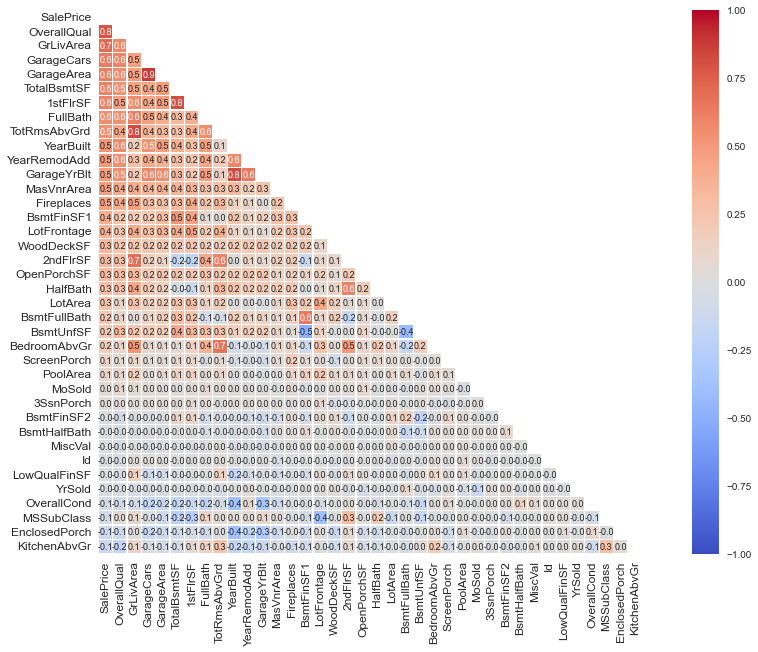

In [35]:
# P1.12 检查训练集相关性，找出高相关特征
corrmat = train.corr()
k=corrmat.shape[0]
cols = corrmat.nlargest(k, 'SalePrice')['SalePrice'].index
cm = (pd.DataFrame(train[cols].values)).corr()
mask = np.zeros_like(cm, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True
f, ax = plt.subplots(figsize=(18, 10))
sns.heatmap(cm,mask=mask,annot=True,fmt='.1f',cmap="coolwarm",vmax=1,vmin=-1,square=True,
            linewidths=.2,annot_kws={'size': 9},yticklabels=cols.values,xticklabels=cols.values)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
for i in range(0,k):
    for j in range(0,k):
        if (cm[i][j]>0.8 and i < j):
            print(cols[i] + '与'+ cols[j]+'相关性 ={:.2f}'.format(cm[i][j]))

In [36]:
# P1.12 删除特征列（高度相关或单一取值超过85%）
combined3 = combined2.drop(['TotRmsAbvGrd', 'GarageCars', '1stFlrSF' ,'GarageYrBlt'], axis=1)
drop_col = []
# 计算每列最大值的占比
max_ratio = combined3.apply(lambda x: x.value_counts().max() / len(x) if len(x.value_counts()) > 0 else 0)
# 筛选出占比超过85%的列
drop_col = max_ratio[max_ratio > 0.85].index.tolist()

# 打印结果
for col in drop_col:
    print('{0} , {1:.4f}'.format(col, max_ratio[col]))

combined3 = combined3.drop(drop_col, axis=1)
print(combined3.shape)

Street , 0.9959
LandContour , 0.8983
Utilities , 0.9997
LandSlope , 0.9517
Condition1 , 0.8602
Condition2 , 0.9897
RoofMatl , 0.9853
ExterCond , 0.8695
BsmtCond , 0.8928
BsmtFinType2 , 0.8541
BsmtFinSF2 , 0.8811
Heating , 0.9846
CentralAir , 0.9329
Electrical , 0.9154
LowQualFinSF , 0.9863
BsmtHalfBath , 0.9400
KitchenAbvGr , 0.9541
Functional , 0.9315
GarageQual , 0.8921
GarageCond , 0.9092
PavedDrive , 0.9048
3SsnPorch , 0.9873
ScreenPorch , 0.9123
PoolArea , 0.9955
MiscVal , 0.9647
SaleType , 0.8654
(2919, 43)


In [37]:
# P1.12 数值型转类别型
combined3[['MoSold','MSSubClass','YrSold']]= combined3[['MoSold','MSSubClass','YrSold']].astype(str)

In [38]:
# P1.12 One-Hot 编码
combined_new=pd.get_dummies(combined3)
print("数据集编码前的维度：",combined3.shape)
print("数据集编码后的维度：",combined_new.shape)
print("数据集新增了 ",combined_new.shape[1]- combined3.shape[1], '个编码特征')

数据集编码前的维度： (2919, 43)
数据集编码后的维度： (2919, 199)
数据集新增了  156 个编码特征


In [39]:
combined_new.head()

,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtUnfSF,TotalBsmtSF,2ndFlrSF,...,YrSold_2007,YrSold_2008,YrSold_2009,YrSold_2010,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,8450,7,5,2003,2003,196.0,706.0,150.0,856.0,854,...,0,1,0,0,0,0,0,0,1,0
1,9600,6,8,1976,1976,0.0,978.0,284.0,1262.0,0,...,1,0,0,0,0,0,0,0,1,0
2,11250,7,5,2001,2002,162.0,486.0,434.0,920.0,866,...,0,1,0,0,0,0,0,0,1,0
3,9550,7,5,1915,1970,0.0,216.0,540.0,756.0,756,...,0,0,0,0,1,0,0,0,0,0
4,14260,8,5,2000,2000,350.0,655.0,490.0,1145.0,1053,...,0,1,0,0,0,0,0,0,1,0


In [40]:
# P1.12 对数变换，正态分布调整
cols = ['GrLivArea','TotalBsmtSF','GarageArea','LotArea',
        'YearBuilt','YearRemodAdd','BsmtFinSF1','BsmtUnfSF']
for col in cols:
    combined_new[col] = np.log1p(combined_new[col])
train_label['SalePrice'] = np.log1p(train_label['SalePrice'])

In [41]:
# P1.13 合并集拆分为训练集与测试集
train = combined_new[:rows_train] 
test = combined_new[rows_train:] 
print(train.shape)
print(test.shape)
print(train_label.shape)

(1460, 199)
(1459, 199)
(1460, 1)


In [42]:
# P1.13 训练集进一步划分为训练与验证两部分
from sklearn.model_selection import train_test_split
x=train
y=np.array(train_label)
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size = .33, random_state=0)

In [43]:
# P1.13 标准化训练集、验证集与测试集
from sklearn.preprocessing import RobustScaler
scaler= RobustScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
X_train= scaler.transform(train)
X_test= scaler.transform(test)

In [44]:
# P1.14 线性回归模型
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_squared_error, r2_score
import math
model_result = []
lr_mod = LinearRegression().fit(x_train, y_train)
y_train_pred = lr_mod.predict(x_train)
y_val_pred = lr_mod.predict(x_val)
RMSE_train = math.sqrt(mean_squared_error(y_train, y_train_pred))
RMSE_val = math.sqrt(mean_squared_error(y_val, y_val_pred))
r2_train = r2_score(y_train, y_train_pred)
r2_val = r2_score(y_val, y_val_pred)
lr_mod_result = {'RMSE_train':RMSE_train, 'RMSE_val':RMSE_val, 'r2_train':r2_train, 'r2_val':r2_val}
print("训练集均方根误差：{0:.2f}，训练集决定系数：{1:.2f}".format(round(RMSE_train,2),round(r2_train,2)))
print("验证集均方根误差：{0:.2f}，验证集决定系数：{1:.2f}".format(round(RMSE_val,2),round(r2_val,2)))

训练集均方根误差：0.10，训练集决定系数：0.93
验证集均方根误差：0.14，验证集决定系数：0.86


In [45]:
# P1.15 岭回归模型
from sklearn.linear_model import RidgeCV
ridge_mod = RidgeCV().fit(x_train, y_train)
y_train_pred = ridge_mod.predict(x_train)
y_val_pred = ridge_mod.predict(x_val)
RMSE_train = math.sqrt(mean_squared_error(y_train, y_train_pred))
RMSE_val = math.sqrt(mean_squared_error(y_val, y_val_pred))
r2_train = r2_score(y_train, y_train_pred)
r2_val = r2_score(y_val, y_val_pred)
ridge_mod_result = {'RMSE_train':RMSE_train, 'RMSE_val':RMSE_val, 'r2_train':r2_train, 'r2_val':r2_val}
print("训练集均方根误差：{0:.2f}，训练集决定系数：{1:.2f}".format(round(RMSE_train,2),round(r2_train,2)))
print("验证集均方根误差：{0:.2f}，验证集决定系数：{1:.2f}".format(round(RMSE_val,2),round(r2_val,2)))

训练集均方根误差：0.11，训练集决定系数：0.93
验证集均方根误差：0.13，验证集决定系数：0.88


In [46]:
# P1.16 Lasso回归模型
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
parameters = {'alpha':[0.0001,0.0009,0.001,0.002,0.003,0.01,0.1,1,10,100]}
lasso = Lasso(max_iter=30000)
lasso_cv = GridSearchCV(lasso, parameters, cv=10)
lasso_cv.fit(x_train,y_train)
print('最佳 alpha 参数取值: ',lasso_cv.best_params_)
lasso_mod = Lasso(alpha = lasso_cv.best_params_['alpha'],max_iter=30000)
lasso_mod.fit(x_train,y_train)
y_train_pred = lasso_mod.predict(x_train)
y_val_pred = lasso_mod.predict(x_val)
RMSE_train = math.sqrt(mean_squared_error(y_train, y_train_pred))
RMSE_val = math.sqrt(mean_squared_error(y_val, y_val_pred))
r2_train = r2_score(y_train, y_train_pred)
r2_val = r2_score(y_val, y_val_pred)
lasso_mod_result = {'RMSE_train':RMSE_train, 'RMSE_val':RMSE_val, 'r2_train':r2_train, 'r2_val':r2_val}
print("训练集均方根误差：{0:.2f}，训练集决定系数：{1:.2f}".format(round(RMSE_train,2),round(r2_train,2)))
print("验证集均方根误差：{0:.2f}，验证集决定系数：{1:.2f}".format(round(RMSE_val,2),round(r2_val,2)))

最佳 alpha 参数取值:  {'alpha': 0.0009}
训练集均方根误差：0.12，训练集决定系数：0.92
验证集均方根误差：0.13，验证集决定系数：0.89


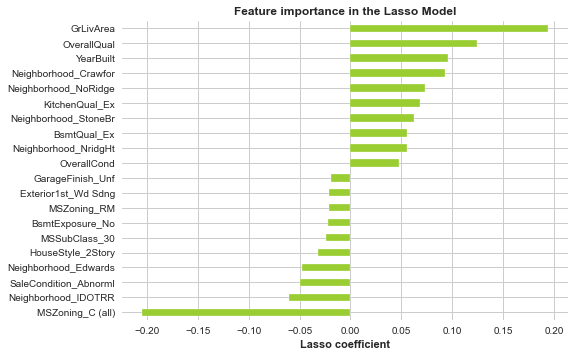

Lasso 保留了  84 个重要特征，舍弃了  115  个非重要特征


In [47]:
# P1.16 查看 Lasso 回归模型中对房价影响最大的特征
coefs = pd.Series(lasso_mod.coef_, index = train.columns)
imp_coefs = pd.concat([coefs.sort_values().head(10),
                     coefs.sort_values().tail(10)])
imp_coefs.plot(kind = "barh", color='yellowgreen')
plt.xlabel("Lasso coefficient", weight='bold')
plt.title("Feature importance in the Lasso Model", weight='bold')
plt.show()
print("Lasso 保留了 ",sum(coefs != 0), "个重要特征，舍弃了 ", sum(coefs == 0)," 个非重要特征")

In [48]:
# P1.17 ElasticNet回归模型
from sklearn.linear_model import ElasticNetCV
alphas = [10,1,0.1,0.01,0.001,0.002,0.003,0.004]
l1ratio = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1]
elastic_cv = ElasticNetCV(cv=5, max_iter=1e7, alphas=alphas,  l1_ratio=l1ratio)
elastic_mod = elastic_cv.fit(x_train, y_train.ravel())
print("模型最优alpha参数：{0}，最优l1ratio参数：{1}".format(elastic_mod.alpha_, elastic_mod.l1_ratio_))
y_train_pred = elastic_mod.predict(x_train)
y_val_pred = elastic_mod.predict(x_val)
RMSE_train = math.sqrt(mean_squared_error(y_train, y_train_pred))
RMSE_val = math.sqrt(mean_squared_error(y_val, y_val_pred))
r2_train = r2_score(y_train, y_train_pred)
r2_val = r2_score(y_val, y_val_pred)
elastic_mod_result = {'RMSE_train':RMSE_train, 'RMSE_val':RMSE_val, 'r2_train':r2_train, 'r2_val':r2_val}
print("训练集均方根误差：{0:.2f}，训练集决定系数：{1:.2f}".format(round(RMSE_train,2),round(r2_train,2)))
print("验证集均方根误差：{0:.2f}，验证集决定系数：{1:.2f}".format(round(RMSE_val,2),round(r2_val,2)))

模型最优alpha参数：0.001，最优l1ratio参数：0.3
训练集均方根误差：0.11，训练集决定系数：0.93
验证集均方根误差：0.13，验证集决定系数：0.88


In [49]:
# P1.18 XGBRegressor 回归模型
from xgboost.sklearn import XGBRegressor
xgbr_mod = XGBRegressor(objective ='reg:squarederror')
xgbr_mod.fit(x_train,y_train)
y_train_pred=xgbr_mod.predict(x_train)
y_val_pred=xgbr_mod.predict(x_val)
RMSE_train = math.sqrt(mean_squared_error(y_train, y_train_pred))
RMSE_val = math.sqrt(mean_squared_error(y_val, y_val_pred))
r2_train = r2_score(y_train, y_train_pred)
r2_val = r2_score(y_val, y_val_pred)
xgbr_mod_result = {'RMSE_train':RMSE_train, 'RMSE_val':RMSE_val, 'r2_train':r2_train, 'r2_val':r2_val}
print("训练集均方根误差：{0:.2f}，训练集决定系数：{1:.2f}".format(round(RMSE_train,2),round(r2_train,2)))
print("验证集均方根误差：{0:.2f}，验证集决定系数：{1:.2f}".format(round(RMSE_val,2),round(r2_val,2)))

训练集均方根误差：0.01，训练集决定系数：1.00
验证集均方根误差：0.14，验证集决定系数：0.87


In [50]:
# P1.19 VotingRegressor 投票回归模型
from sklearn.ensemble import VotingRegressor
vote_reg = VotingRegressor([('Ridge', ridge_mod), ('Lasso', lasso_mod), ('Elastic', elastic_mod), 
                            ('XGBRegressor', xgbr_mod)])
vote_mod = vote_reg.fit(x_train, y_train.ravel())
y_train_pred = vote_mod.predict(x_train)
y_val_pred = vote_mod.predict(x_val)
RMSE_train = math.sqrt(mean_squared_error(y_train, y_train_pred))
RMSE_val = math.sqrt(mean_squared_error(y_val, y_val_pred))
r2_train = r2_score(y_train, y_train_pred)
r2_val = r2_score(y_val, y_val_pred)
vote_mod_result = {'RMSE_train':RMSE_train, 'RMSE_val':RMSE_val, 'r2_train':r2_train, 'r2_val':r2_val}
print("训练集均方根误差：{0:.2f}，训练集决定系数：{1:.2f}".format(round(RMSE_train,2),round(r2_train,2)))
print("验证集均方根误差：{0:.2f}，验证集决定系数：{1:.2f}".format(round(RMSE_val,2),round(r2_val,2)))

训练集均方根误差：0.08，训练集决定系数：0.96
验证集均方根误差：0.12，验证集决定系数：0.90


In [51]:
# P1.20 StackingRegressor 层叠回归模型
from mlxtend.regressor import StackingRegressor
stack_reg = StackingRegressor(regressors=[ridge_mod, lasso_mod, elastic_mod, vote_mod], 
                           meta_regressor=xgbr_mod, use_features_in_secondary=True)
stack_mod=stack_reg.fit(x_train, y_train.ravel())
y_train_pred=stack_mod.predict(x_train)
y_val_pred=stack_mod.predict(x_val)
RMSE_train = math.sqrt(mean_squared_error(y_train, y_train_pred))
RMSE_val = math.sqrt(mean_squared_error(y_val, y_val_pred))
r2_train = r2_score(y_train, y_train_pred)
r2_val = r2_score(y_val, y_val_pred)
stack_mod_result={'RMSE_train':RMSE_train, 'RMSE_val':RMSE_val, 'r2_train':r2_train, 'r2_val':r2_val}
print("训练集均方根误差：{0:.2f}，训练集决定系数：{1:.2f}".format(round(RMSE_train,2),round(r2_train,2)))
print("验证集均方根误差：{0:.2f}，验证集决定系数：{1:.2f}".format(round(RMSE_val,2),round(r2_val,2)))

训练集均方根误差：0.00，训练集决定系数：1.00
验证集均方根误差：0.13，验证集决定系数：0.88


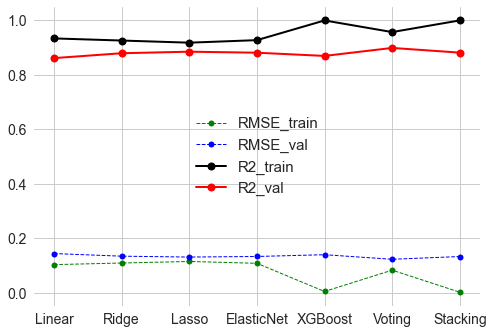

In [52]:
# P1.21 七种回归模型比较
model_result=[lr_mod_result, ridge_mod_result, lasso_mod_result, elastic_mod_result,
              xgbr_mod_result, vote_mod_result, stack_mod_result]
xx = ['Linear','Ridge','Lasso','ElasticNet','XGBoost','Voting','Stacking']
y1 = []
y2 = []
y3 = []
y4 = []
for model in model_result:
    y1.append(model['RMSE_train'])
    y2.append(model['RMSE_val'])
    y3.append(model['r2_train'])
    y4.append(model['r2_val'])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.plot(xx, y1, color='green', marker='o', linestyle='dashed', linewidth=1, markersize=6, label='RMSE_train')
plt.plot(xx, y2, color='blue', marker='o', linestyle='dashed', linewidth=1, markersize=6, label='RMSE_val')
plt.plot(xx, y3, color='black', marker='o', linestyle='solid', linewidth=2, markersize=8, label='R2_train')
plt.plot(xx, y4, color='red', marker='o', linestyle='solid', linewidth=2, markersize=8, label='R2_val')
plt.legend(loc='center', fontsize=15);

In [53]:
# P1.21 应用投票回归模型到测试集
vote_pred = vote_mod.predict(X_test)
vote_pred = np.expm1(vote_pred)
final_submission = pd.DataFrame({
        "Id": test.index+1,
        "SalePrice": vote_pred
    })
final_submission.to_csv("final_submission.csv", index=False)
final_submission.head()

,Id,SalePrice
0,1461,120014.592205
1,1462,163532.330331
2,1463,176380.333846
3,1464,196972.604191
4,1465,183976.033836


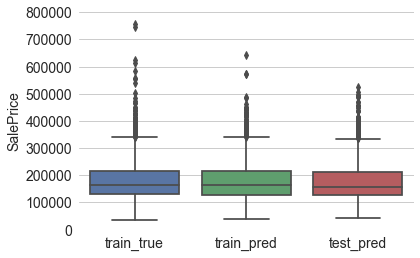

In [54]:
# P1.21 投票回归模型的房价预测效果对比
x_var = 'type'
train_true = np.expm1(train_label['SalePrice'])
train_pred = train_label
train_pred['SalePrice'] = np.expm1(vote_mod.predict(X_train))
test_pred = final_submission['SalePrice']
train_true = pd.DataFrame(train_true)
train_true['type'] = 'train_true'
train_pred = pd.DataFrame(train_pred)
train_pred['type'] = 'train_pred'
test_pred = pd.DataFrame(test_pred)
test_pred['type'] = 'test_pred'
compare_data = pd.concat((train_true, train_pred, test_pred), sort=False).reset_index(drop=True)
f, ax = plt.subplots(figsize=(6, 4))
fig = sns.boxplot(x=x_var, y='SalePrice', data=compare_data)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
ax.set_xlabel('')
plt.ylabel('SalePrice',fontsize = 14)
fig.axis(ymin=0, ymax=800000);